# Complex Contagion Project: Diffusion of Behaviors on Networks

**States:**
- **B (Baseline)**: Blue
- **A (Adopted)**: Cyan (aquamarine)

**Early adopters** start in state A. An agent in B adopts when enough neighbors have adopted (absolute or fractional threshold).

In [2]:
%matplotlib inline
import sys
sys.path.insert(0, "..")

import random
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from src.complex_contagion import (
    BehaviorState,
    ComplexContagionPopulation,
    get_graph_nineteen_four_from_ncm_book,
    get_circulant_20_2,
    get_circulant_20_4,
    get_karate_graph,
    get_scale_free_100,
    get_scale_free_410,
    get_small_world_100,
    get_small_world_410,
    get_infect_dublin,
    select_clustered_seeds,
    select_incubator_seeds,
    select_random_seeds,
    network_summary,
)

## 1. Networks

Nine networks for experimentation:
1. Figure 19.4 (NCM book) – for intuition
2. Circulant 20-2
3. Circulant 20-4
4. Karate club
5. Scale-free 100
6. Scale-free 410
7. Small-world 100
8. Small-world 410
9. Infect-Dublin

In [ ]:
# Build all networks
G_fig19 = get_graph_nineteen_four_from_ncm_book()
G_circ_2 = get_circulant_20_2()
G_circ_4 = get_circulant_20_4()
G_karate = get_karate_graph()  

# Random networks 
G_sf_100 = get_scale_free_100(seed=42)
G_sf_410 = get_scale_free_410(seed=42)
G_sw_100 = get_small_world_100(seed=42)
G_sw_410 = get_small_world_410(seed=42)

# Dublin
dublin_path = "../data/ia-infect-dublin.mtx"
G_dublin = get_infect_dublin(dublin_path)
print("Dublin loaded:", G_dublin.number_of_nodes(), "nodes")

networks_small = [("Circulant 20-2", G_circ_2), ("Circulant 20-4", G_circ_4), ("Karate", G_karate)]
networks_large = [("Scale-free 100", G_sf_100), ("Scale-free 410", G_sf_410),
                  ("Small-world 100", G_sw_100), ("Small-world 410", G_sw_410)]

Dublin loaded: 410 nodes


## 2. Early Adopter Selection

- **Clustered seeding**: Early adopters are neighbors of each other.
- **Incubator neighborhoods**: A handful of seeds within one neighborhood.

In [ ]:
def get_early_adopters(G, strategy="clustered", n_seeds=3, seed=42):
    rng = random.Random(seed)
    if strategy == "clustered":
        return select_clustered_seeds(G, n_seeds, rng=rng)
    elif strategy == "incubator":
        return select_incubator_seeds(G, n_seeds, rng=rng)
    else:
        return select_random_seeds(G, n_seeds, rng=rng)
seeds_clustered = select_clustered_seeds(G_karate, 3, seed_node=0, rng=random.Random(42))
seeds_random = select_random_seeds(G_karate, 3, rng=random.Random(42))
print("Clustered seeds:", seeds_clustered)
print("Random seeds:", seeds_random)

Clustered seeds: {0, 2, 7}
Random seeds: {1, 17, 7}


## 3. Time Dynamics for Small Graphs

Sequence of snapshots showing how the cascade spreads. B=blue, A=cyan.

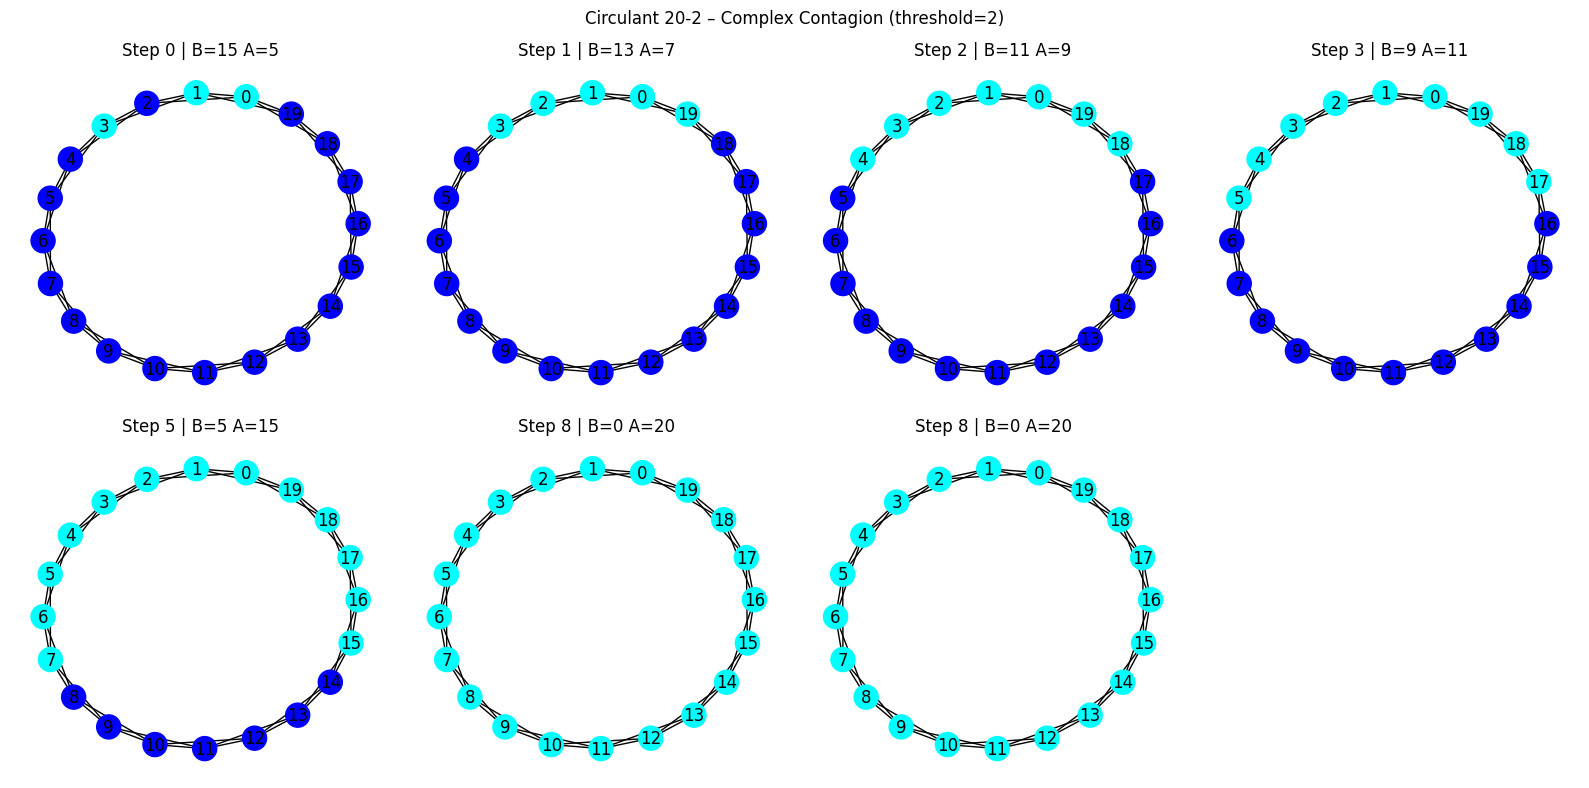

In [ ]:
def run_and_plot_cascade(G, name, early_adopters, threshold=2, threshold_type="absolute", max_steps=20):
    pop = ComplexContagionPopulation(
        G, early_adopters=early_adopters,
        threshold_type=threshold_type, threshold=threshold, seed=42
    )
    history = pop.run(max_steps=max_steps)
    
    # Plot selected steps
    steps_to_show = [0, 1, 2, 3, 5, min(10, len(history)-1), len(history)-1]
    steps_to_show = [s for s in steps_to_show if s < len(history)]
    n_plots = len(steps_to_show)
    
    fig, axes = plt.subplots(2, (n_plots + 1) // 2, figsize=(4 * ((n_plots + 1) // 2), 8))
    axes = axes.flatten() if n_plots > 1 else [axes]
    pos = nx.spring_layout(G, seed=42)
    
    for idx, step in enumerate(steps_to_show):
        # Re-run to get state at step
        pop2 = ComplexContagionPopulation(G, early_adopters=early_adopters,
                                         threshold_type=threshold_type, threshold=threshold, seed=42)
        for _ in range(step):
            pop2.step()
        colors = pop2.get_color_map()
        ax = axes[idx] if n_plots > 1 else axes[0]
        nx.draw(G, pos, node_color=colors, with_labels=True, ax=ax, node_size=300)
        counts = history[step]
        ax.set_title(f"Step {step} | B={counts[BehaviorState.BASELINE]} A={counts[BehaviorState.ADOPTED]}")
    
    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f"{name} – Complex Contagion (threshold={threshold})")
    plt.tight_layout()
    plt.show()
    return history

seeds = select_clustered_seeds(G_circ_2, 3, seed_node=0, rng=random.Random(42))
hist = run_and_plot_cascade(G_circ_2, "Circulant 20-2", seeds, threshold=2)

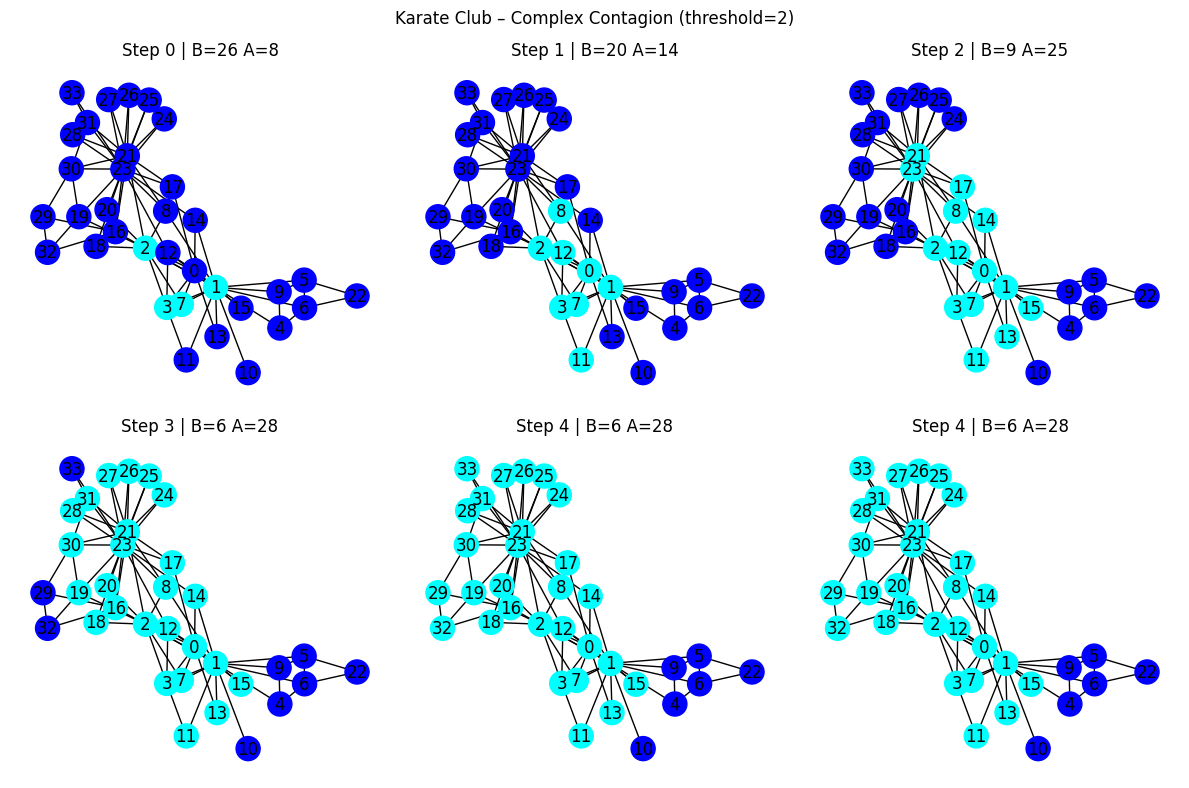

[{<BehaviorState.BASELINE: 'B'>: 26, <BehaviorState.ADOPTED: 'A'>: 8},
 {<BehaviorState.BASELINE: 'B'>: 20, <BehaviorState.ADOPTED: 'A'>: 14},
 {<BehaviorState.BASELINE: 'B'>: 9, <BehaviorState.ADOPTED: 'A'>: 25},
 {<BehaviorState.BASELINE: 'B'>: 6, <BehaviorState.ADOPTED: 'A'>: 28},
 {<BehaviorState.BASELINE: 'B'>: 6, <BehaviorState.ADOPTED: 'A'>: 28}]

In [6]:
# Karate with incubator seeds
seeds_karate = select_incubator_seeds(G_karate, 4, rng=random.Random(42))
run_and_plot_cascade(G_karate, "Karate Club", seeds_karate, threshold=2)

## 4. Time Dynamics for Larger Graphs

Plot adoption over time. For random networks (small-world, scale-free), run multiple trials and plot mean ± IQR.

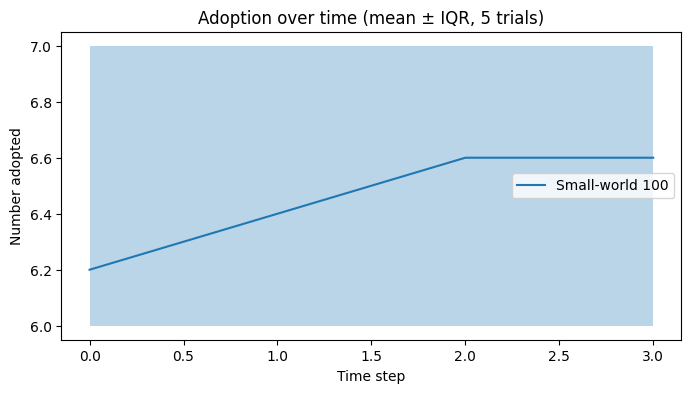

In [ ]:
def run_trials(G, n_trials, early_adopters_fn, threshold=2, threshold_type="absolute", max_steps=200):
    """Run n_trials and return list of adoption curves."""
    curves = []
    for i in range(n_trials):
        seeds = early_adopters_fn(G, i)
        pop = ComplexContagionPopulation(G, early_adopters=seeds,
                                        threshold_type=threshold_type, threshold=threshold, seed=100 + i)
        hist = pop.run(max_steps=max_steps)
        curves.append(pop.get_adoption_curve(hist))
    return curves

def plot_adoption_curves(curves, name, ax=None):
    """Plot mean and IQR of adoption over time."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    max_len = max(len(c) for c in curves)
    # Pad shorter curves with last value
    padded = []
    for c in curves:
        if len(c) < max_len:
            c = c + [c[-1]] * (max_len - len(c))
        padded.append(c)
    arr = np.array(padded)
    mean = np.mean(arr, axis=0)
    q25 = np.percentile(arr, 25, axis=0)
    q75 = np.percentile(arr, 75, axis=0)
    ax.plot(mean, label=name)
    ax.fill_between(range(len(mean)), q25, q75, alpha=0.3)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Number adopted")
    ax.legend()
    return ax

# Check the curve
def make_seeds_sw(G, trial):
    return select_clustered_seeds(G, 5, rng=random.Random(200 + trial))

curves_sw = run_trials(G_sw_100, 5, make_seeds_sw, threshold=2)
plot_adoption_curves(curves_sw, "Small-world 100")
plt.title("Adoption over time (mean ± IQR, 5 trials)")
plt.show()

## 5. Summarizing Results for Larger Graphs

Table: time-to-stop, % adopting, clustering coefficient, density, avg path length.

In [22]:
def summarize_run(history, G):
    n = G.number_of_nodes()
    final_adopted = history[-1][BehaviorState.ADOPTED]
    pct_adopted = 100 * final_adopted / n
    time_to_stop = len(history)
    return {"time_to_stop": time_to_stop, "pct_adopted": pct_adopted, "final_adopted": final_adopted}

def run_summary_table(networks, n_trials=5, seed_base=300):
    rows = []
    for name, G in networks:
        stats = network_summary(G)
        times, pcts = [], []
        for i in range(n_trials):
            seeds = select_clustered_seeds(G, min(5, G.number_of_nodes() // 20), rng=random.Random(seed_base + i))
            pop = ComplexContagionPopulation(G, early_adopters=seeds, threshold=2, seed=seed_base + i)
            hist = pop.run(max_steps=500)
            s = summarize_run(hist, G)
            times.append(s["time_to_stop"])
            pcts.append(s["pct_adopted"])
        row = {
            "Network": name,
            "n_nodes": stats["n_nodes"],
            "Clustering": round(stats["clustering"], 4),
            "Density": round(stats["density"], 4),
            "Avg degree": round(stats["avg_degree"], 2),
            "Time to stop": f"{np.mean(times):.1f} ± {np.std(times):.1f}" if n_trials > 1 else times[0],
            "% Adopted": f"{np.mean(pcts):.1f} ± {np.std(pcts):.1f}" if n_trials > 1 else f"{pcts[0]:.1f}",
        }
        rows.append(row)
    return pd.DataFrame(rows)

df = run_summary_table(networks_large, n_trials=5)
display(df)

,Network,n_nodes,Clustering,Density,Avg degree,Time to stop,% Adopted
0,Scale-free 100,100,0.1634,0.0396,3.92,9.4 ± 1.0,100.0 ± 0.0
1,Scale-free 410,410,0.0706,0.0097,3.98,8.4 ± 5.6,42.0 ± 47.4
2,Small-world 100,100,0.2026,0.0404,4.00,4.6 ± 1.7,11.4 ± 3.3
3,Small-world 410,410,0.0081,0.0049,2.00,2.0 ± 0.0,1.2 ± 0.0


In [ ]:

df_dublin = run_summary_table([("Dublin", G_dublin)], n_trials=5, seed_base=400)
display(df_dublin)

,Network,n_nodes,Clustering,Density,Avg degree,Time to stop,% Adopted
0,Dublin,410,0.4558,0.033,13.49,10.6 ± 1.4,97.1 ± 0.0


## 6. Fractional vs Absolute Threshold

Compare fractional threshold (e.g., 50% of neighbors) vs absolute (e.g., 2 neighbors).

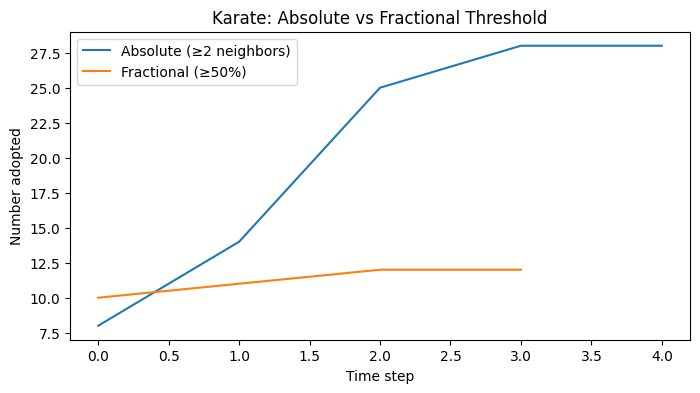

In [9]:
# Absolute: need at least 2 adopting neighbors
pop_abs = ComplexContagionPopulation(G_karate, early_adopters=seeds_karate, threshold_type="absolute", threshold=2, seed=42)
hist_abs = pop_abs.run(max_steps=50)

# Fractional: need at least 50% of neighbors to have adopted
pop_frac = ComplexContagionPopulation(G_karate, early_adopters=seeds_karate, threshold_type="fractional", threshold=0.5, seed=42)
hist_frac = pop_frac.run(max_steps=50)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([h[BehaviorState.ADOPTED] for h in hist_abs], label="Absolute (≥2 neighbors)")
ax.plot([h[BehaviorState.ADOPTED] for h in hist_frac], label="Fractional (≥50%)")
ax.set_xlabel("Time step")
ax.set_ylabel("Number adopted")
ax.legend()
ax.set_title("Karate: Absolute vs Fractional Threshold")
plt.show()

## 7. Build Intuition

In [10]:
def nodes_by_degree(G, n, highest=True):
    """Return the n nodes with highest (or lowest) degree."""
    degrees = [(node, G.degree(node)) for node in G.nodes()]
    degrees.sort(key=lambda x: x[1], reverse=highest)
    return set(node for node, _ in degrees[:n])

def run_experiment(G, early_adopters, threshold=2, threshold_type="absolute", max_steps=500):
    """Run one experiment and return final adopted count and %."""
    pop = ComplexContagionPopulation(G, early_adopters=early_adopters,
        threshold_type=threshold_type, threshold=threshold, seed=42)
    hist = pop.run(max_steps=max_steps)
    n = G.number_of_nodes()
    final = hist[-1][BehaviorState.ADOPTED]
    return final, 100 * final / n, len(hist)

In [ ]:
G = G_fig19
results_fig19 = []
for thresh_type, thresh in [("absolute", 2), ("fractional", 0.5)]:
    for seeds, label in [
        ({1, 2}, "1 and 2"),
        ({7, 8}, "7 and 8"),
        ({6, 7, 12}, "6, 7, 12"),
    ]:
        final, pct, steps = run_experiment(G, seeds, threshold=thresh, threshold_type=thresh_type)
        results_fig19.append({"threshold": thresh_type, "seeds": label, "adopted": final, "%": round(pct, 1), "steps": steps})
pd.DataFrame(results_fig19)

,threshold,seeds,adopted,%,steps
0,absolute,1 and 2,3,17.6,2
1,absolute,7 and 8,7,41.2,4
2,absolute,"6, 7, 12",14,82.4,7
3,fractional,1 and 2,3,17.6,2
4,fractional,7 and 8,7,41.2,4
5,fractional,"6, 7, 12",14,82.4,7


In [12]:
# --- Circulant 20-2 ---
G = get_circulant_20_2()
results_circ2 = []
for thresh_type, thresh in [("absolute", 2), ("fractional", 0.5)]:
    for seeds, label in [({1, 2}, "1 and 2"), ({1, 10}, "1 and 10")]:
        final, pct, steps = run_experiment(G, seeds, threshold=thresh, threshold_type=thresh_type)
        results_circ2.append({"threshold": thresh_type, "seeds": label, "adopted": final, "%": round(pct, 1), "steps": steps})
pd.DataFrame(results_circ2)

,threshold,seeds,adopted,%,steps
0,absolute,1 and 2,20,100.0,10
1,absolute,1 and 10,2,10.0,2
2,fractional,1 and 2,20,100.0,10
3,fractional,1 and 10,2,10.0,2


In [13]:
# --- Circulant 20-4 ---
G = get_circulant_20_4()
results_circ4 = []
for thresh_type, thresh in [("absolute", 2), ("fractional", 0.5)]:
    for seeds, label in [
        ({1, 2}, "1 and 2"),
        ({1, 2, 3, 4}, "1, 2, 3, 4"),
    ]:
        final, pct, steps = run_experiment(G, seeds, threshold=thresh, threshold_type=thresh_type)
        results_circ4.append({"threshold": thresh_type, "seeds": label, "adopted": final, "%": round(pct, 1), "steps": steps})
pd.DataFrame(results_circ4)

,threshold,seeds,adopted,%,steps
0,absolute,1 and 2,20,100.0,4
1,absolute,"1, 2, 3, 4",20,100.0,4
2,fractional,1 and 2,2,10.0,2
3,fractional,"1, 2, 3, 4",20,100.0,8


In [14]:
# --- Karate ---
G = G_karate
results_karate = []
for thresh_type, thresh in [("absolute", 2), ("fractional", 0.5)]:
    for seeds, label in [
        ({0, 1}, "1 and 2 (first two)"),
        ({32, 33}, "33 and 34 (last two)"),
    ]:
        final, pct, steps = run_experiment(G, seeds, threshold=thresh, threshold_type=thresh_type)
        results_karate.append({"threshold": thresh_type, "seeds": label, "adopted": final, "%": round(pct, 1), "steps": steps})
pd.DataFrame(results_karate)

,threshold,seeds,adopted,%,steps
0,absolute,1 and 2 (first two),28,82.4,6
1,absolute,33 and 34 (last two),2,5.9,2
2,fractional,1 and 2 (first two),12,35.3,6
3,fractional,33 and 34 (last two),2,5.9,2


In [15]:
# --- Small world 100: 4 lowest degree, 4 highest degree ---
G = G_sw_100
seeds_low = nodes_by_degree(G, 4, highest=False)
seeds_high = nodes_by_degree(G, 4, highest=True)
results_sw100 = []
for thresh_type, thresh in [("absolute", 2), ("fractional", 0.5)]:
    for seeds, label in [(seeds_low, "4 lowest degree"), (seeds_high, "4 highest degree")]:
        final, pct, steps = run_experiment(G, seeds, threshold=thresh, threshold_type=thresh_type)
        results_sw100.append({"threshold": thresh_type, "seeds": label, "adopted": final, "%": round(pct, 1), "steps": steps})
pd.DataFrame(results_sw100)

,threshold,seeds,adopted,%,steps
0,absolute,4 lowest degree,4,4.0,2
1,absolute,4 highest degree,5,5.0,2
2,fractional,4 lowest degree,4,4.0,2
3,fractional,4 highest degree,7,7.0,2


In [16]:
# --- Scale free 100: 4 lowest degree, 4 highest degree ---
G = G_sf_100
seeds_low = nodes_by_degree(G, 4, highest=False)
seeds_high = nodes_by_degree(G, 4, highest=True)
results_sf100 = []
for thresh_type, thresh in [("absolute", 2), ("fractional", 0.5)]:
    for seeds, label in [(seeds_low, "4 lowest degree"), (seeds_high, "4 highest degree")]:
        final, pct, steps = run_experiment(G, seeds, threshold=thresh, threshold_type=thresh_type)
        results_sf100.append({"threshold": thresh_type, "seeds": label, "adopted": final, "%": round(pct, 1), "steps": steps})
pd.DataFrame(results_sf100)

,threshold,seeds,adopted,%,steps
0,absolute,4 lowest degree,100,100.0,10
1,absolute,4 highest degree,100,100.0,8
2,fractional,4 lowest degree,4,4.0,2
3,fractional,4 highest degree,100,100.0,9


In [17]:
# --- Small world 410: 20 highest degree ---
G = G_sw_410
seeds_high = nodes_by_degree(G, 20, highest=True)
results_sw410 = []
for thresh_type, thresh in [("absolute", 2), ("fractional", 0.5)]:
    final, pct, steps = run_experiment(G, seeds_high, threshold=thresh, threshold_type=thresh_type)
    results_sw410.append({"threshold": thresh_type, "seeds": "20 highest", "adopted": final, "%": round(pct, 1), "steps": steps})
pd.DataFrame(results_sw410)

,threshold,seeds,adopted,%,steps
0,absolute,20 highest,23,5.6,2
1,fractional,20 highest,139,33.9,13


In [18]:
# --- Scale free 410: 20 highest, 50 highest degree ---
G = G_sf_410
results_sf410 = []
for thresh_type, thresh in [("absolute", 2), ("fractional", 0.5)]:
    for n, label in [(20, "20 highest"), (50, "50 highest")]:
        seeds = nodes_by_degree(G, n, highest=True)
        final, pct, steps = run_experiment(G, seeds, threshold=thresh, threshold_type=thresh_type)
        results_sf410.append({"threshold": thresh_type, "seeds": label, "adopted": final, "%": round(pct, 1), "steps": steps})
pd.DataFrame(results_sf410)

,threshold,seeds,adopted,%,steps
0,absolute,20 highest,410,100.0,9
1,absolute,50 highest,410,100.0,9
2,fractional,20 highest,410,100.0,13
3,fractional,50 highest,410,100.0,6


In [20]:
# --- Dublin: 50 highest degree ---

G = G_dublin
seeds = nodes_by_degree(G, 50, highest=True)
results_dublin = []
for thresh_type, thresh in [("absolute", 2), ("fractional", 0.5)]:
    final, pct, steps = run_experiment(G, seeds, threshold=thresh, threshold_type=thresh_type)
    results_dublin.append({"threshold": thresh_type, "seeds": "50 highest", "adopted": final, "%": round(pct, 1), "steps": steps})
pd.DataFrame(results_dublin)

,threshold,seeds,adopted,%,steps
0,absolute,50 highest,398,97.1,5
1,fractional,50 highest,148,36.1,17
